In [1]:
# Load the libraries you will need
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Perceptron
from pandas import *

from sklearn.metrics import confusion_matrix

%matplotlib inline

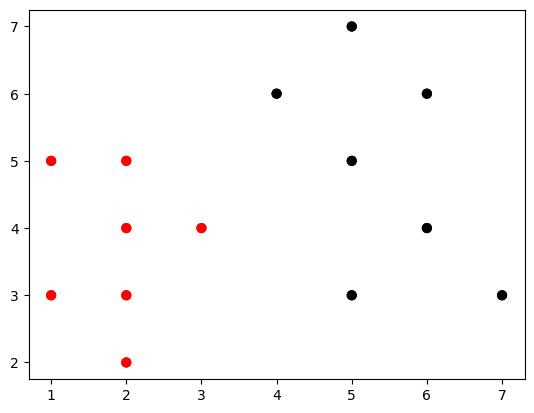

In [2]:

# Put some data into a dataframe
inputs = DataFrame({
'A' : [2, 1, 2, 5, 7, 2, 3, 6, 1, 2, 5, 4, 6, 5],
'B' : [2, 3, 3, 3, 3, 4, 4, 4, 5, 5, 5, 6, 6, 7],
'Targets' : [0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1]
})

# Set an array of colours, we could call it
# anything but here we call is colormap
# It sounds more awesome
colormap = np.array(['r', 'k'])

# Plot the data, A is x axis, B is y axis
# and the colormap is applied based on the Targets
plt.scatter(inputs.A, inputs.B, c=colormap[inputs.Targets], s=40)

# Set an array of colours, we could call it
# anything but here we call is colormap
# It sounds more awesome
colormap = np.array(['r', 'k'])
 
# Plot the data, A is x axis, B is y axis
# and the colormap is applied based on the Targets
plt.scatter(inputs.A, inputs.B, c=colormap[inputs.Targets], s=40)



In [ ]:
# Create the perceptron object (net)
# We initialize the model with specific hyperparameters that control how it learns.
net = Perceptron(
    max_iter=100,      # The maximum number of passes over the training data (epochs).
    verbose=0,         # Controls logs; 0 means "silent" (no output during training).
    random_state=None, # Seed for the shuffle; 'None' means results may vary slightly each run.
    fit_intercept=True,# Determines if the model calculates the 'bias' (y-intercept).
    eta0=0.002         # The learning rate; determines the step size at each iteration.
)

# Train the perceptron object (net)
# It adjusts the weights based on the 'A' and 'B' features to predict the 'Targets'.
net.fit(inputs[['A', 'B']], inputs['Targets'])

In [4]:

# Output the coefficints
print ("Coefficient 0 :" + str(net.coef_[0,0]))
print ("Coefficient 1 :" + str(net.coef_[0,1]))
print ("Bias :" + str(net.intercept_))

Coefficient 0 :0.036000000000000004
Coefficient 1 :-0.016000000000000007
Bias :[-0.032]


In [6]:
#result
print(f"Weights (w1, w2): {net.coef_}") # the Weights (Coefficients) assigned to 'A' and 'B'
print(f"Bias (b): {net.intercept_}") # the Bias (Intercept)
print(f"Iterations: {net.n_iter_}") #Total Number of Iterations it took to converge

accuracy = net.score(inputs[['A', 'B']], inputs['Targets'])
print(f"Training Accuracy: {accuracy * 100:.2f}%") #Accuracy Score

Weights (w1, w2): [[ 0.036 -0.016]]
Bias (b): [-0.032]
Iterations: 13
Training Accuracy: 85.71%


**Decision Boundary visualization for a Perceptron**


The Logic: In a Perceptron, the boundary occurs where the net input is zero:$$w_0x + w_1y + b = 0$$Rearranging for $y$:$$w_1y = -w_0x - b \implies y = \left(-\frac{w_0}{w_1}\right)x - \frac{b}{w_1}$$a: This represents the slope ($-\frac{w_0}{w_1}$).

yy: This calculates the $y$-coordinates across the range of $x$ values (xx).

(0.0, 8.0)

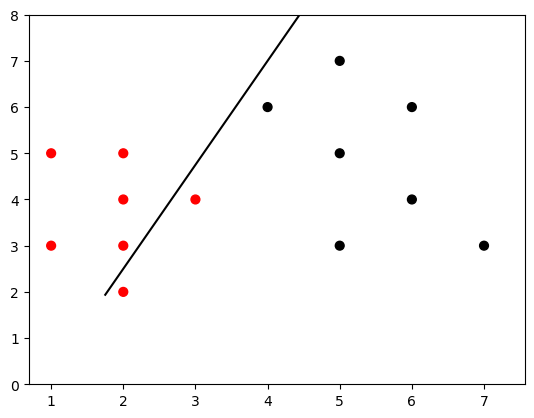

In [5]:
# Plot the original data
plt.scatter(inputs.A, inputs.B, c=colormap[inputs.Targets], s=40)

# Calc the hyperplane (decision boundary)
ymin, ymax = plt.ylim()
w = net.coef_[0]
a = -w[0] / w[1]
xx = np.linspace(ymin, ymax)
yy = a * xx - (net.intercept_[0]) / w[1]
 
# Plot the hyperplane
plt.plot(xx,yy, 'k-')
plt.ylim([0,8]) # Limit the y axis size


In [9]:
# Do a prediction
pred = net.predict(inputs[['A','B']])
print (pred)   
 
# Confusion Matrix
confusion_matrix(pred, inputs['Targets'])

[1 0 0 1 1 0 1 1 0 0 1 1 1 1]


array([[5, 0],
       [2, 7]], dtype=int64)

In [30]:
#Homework
#Try this data to…

#Use in the prediction of this model, how well does the system perform?
#Rebuild the full model using this data
#See how the hyperplane has moved?

# Different Data
inputs = DataFrame({
'A' :       [1,1,1,1,2,2,2,2,3,3,3,3,4,4,4,4,5,5,5,5],
'B' :       [1,2,3,4,1,2,3,4,1,2,3,4,1,2,3,4,1,2,3,4],
'Targets' : [0,0,0,0,0,0,0,0,1,1,0,0,1,1,1,0,1,1,1,1]
})

In [ ]:
#XOR!!!! Is it possible?

# Different Data
inputs = DataFrame({
'A' :       [1,1,0,0],
'B' :       [1,0,0,1],
'Targets' : [1,0,0,0]
})

In [ ]:
#Homework answer

In [13]:
# Different Data
inputs = DataFrame({
'A' :       [1,1,1,1,2,2,2,2,3,3,3,3,4,4,4,4,5,5,5,5],
'B' :       [1,2,3,4,1,2,3,4,1,2,3,4,1,2,3,4,1,2,3,4],
'Targets' : [0,0,0,0,0,0,0,0,1,1,0,0,1,1,1,0,1,1,1,1]
})

Weights (w1, w2): [[ 0.02 -0.02]]
Bias (b): [-0.014]
Training Accuracy: 95.00%


(0.0, 8.0)

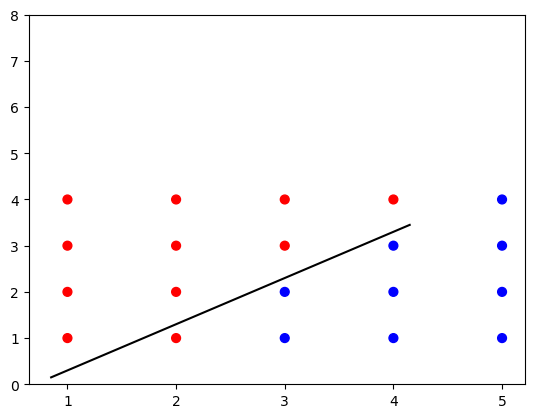

In [31]:
net = Perceptron(max_iter=100, verbose=0, random_state=None, fit_intercept=True, eta0=0.002         )
# Train the perceptron object (net)
net.fit(inputs[['A', 'B']], inputs['Targets'])

print(f"Weights (w1, w2): {net.coef_}") # the Weights (Coefficients) assigned to 'A' and 'B'
print(f"Bias (b): {net.intercept_}") # the Bias (Intercept)
accuracy = net.score(inputs[['A', 'B']], inputs['Targets'])
print(f"Training Accuracy: {accuracy * 100:.2f}%") #Accuracy Score

# Plot the original data
plt.scatter(inputs.A, inputs.B, c=colormap[inputs.Targets], s=40)

# Calc the hyperplane (decision boundary)
ymin, ymax = plt.ylim()
w = net.coef_[0]
a = -w[0] / w[1]
xx = np.linspace(ymin, ymax)
yy = a * xx - (net.intercept_[0]) / w[1]
 
# Plot the hyperplane
plt.plot(xx,yy, 'k-')
plt.ylim([0,8]) # Limit the y axis size


In [34]:
# Comments: 
# the targets are more intermingled, which will force the hyperplane to shift and may result in some misclassifications.

In [26]:
# Different Data
inputs = DataFrame({
'A' :       [1,1,0,0],
'B' :       [1,0,0,1],
'Targets' : [1,0,0,0]
})

Weights (w1, w2): [[0.004 0.006]]
Bias (b): [-0.004]
Training Accuracy: 75.00%


(0.0, 8.0)

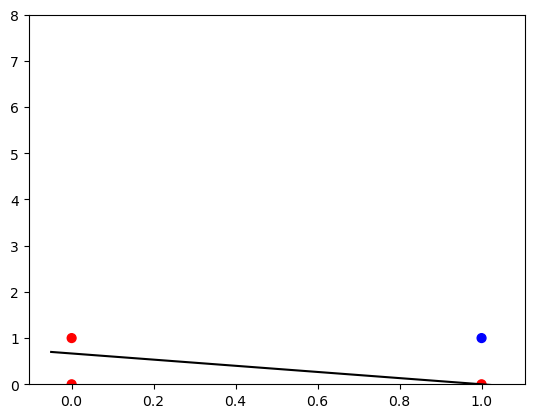

In [28]:
net = Perceptron(max_iter=100, verbose=0, random_state=None, fit_intercept=True, eta0=0.002         )
# Train the perceptron object (net)
net.fit(inputs[['A', 'B']], inputs['Targets'])

print(f"Weights (w1, w2): {net.coef_}") # the Weights (Coefficients) assigned to 'A' and 'B'
print(f"Bias (b): {net.intercept_}") # the Bias (Intercept)
accuracy = net.score(inputs[['A', 'B']], inputs['Targets'])
print(f"Training Accuracy: {accuracy * 100:.2f}%") #Accuracy Score

# Plot the original data
plt.scatter(inputs.A, inputs.B, c=colormap[inputs.Targets], s=40)

# Calc the hyperplane (decision boundary)
ymin, ymax = plt.ylim()
w = net.coef_[0]
a = -w[0] / w[1]
xx = np.linspace(ymin, ymax)
yy = a * xx - (net.intercept_[0]) / w[1]
 
# Plot the hyperplane
plt.plot(xx,yy, 'k-')
plt.ylim([0,8]) # Limit the y axis size
